# Los Angeles Crime Dataset Exploratory Analisys


The CSV file below is a dataset of crime incidents in the City of Los Angeles from 2020 to present (2025), and We object to do an EDA (Exploratory Data Analisys) on this data.

---



# 1) ELT (Extract, Load and Transform)

## 1.1) Extract

Firstly, We'll prepare the libraries and CSV file first:

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, f_oneway


df = pd.read_csv(f"https://data.lacity.org/api/views/2nrs-mtv8/rows.csv")

Now We need to see it head and tail as an data frame, let's take a look:

In [2]:
df.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,211507896,04/11/2021 12:00:00 AM,11/07/2020 12:00:00 AM,845,15,N Hollywood,1502,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,NaN,NaN,NaN,7800 BEEMAN AV,NaN,34.2124,-118.4092
1,201516622,10/21/2020 12:00:00 AM,10/18/2020 12:00:00 AM,1845,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,IC,Invest Cont,230.0,NaN,NaN,NaN,ATOLL AV,N GAULT,34.1993,-118.4203
2,240913563,12/10/2024 12:00:00 AM,10/30/2020 12:00:00 AM,1240,9,Van Nuys,933,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,NaN,NaN,NaN,14600 SYLVAN ST,NaN,34.1847,-118.4509
3,210704711,12/24/2020 12:00:00 AM,12/24/2020 12:00:00 AM,1310,7,Wilshire,782,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,...,IC,Invest Cont,331.0,NaN,NaN,NaN,6000 COMEY AV,NaN,34.0339,-118.3747
4,201418201,10/03/2020 12:00:00 AM,09/29/2020 12:00:00 AM,1830,14,Pacific,1454,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),...,IC,Invest Cont,420.0,NaN,NaN,NaN,4700 LA VILLA MARINA,NaN,33.9813,-118.4350


In [3]:
df.tail()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
1004986,252104112,02/02/2025 12:00:00 AM,02/02/2025 12:00:00 AM,130,21,Topanga,2103,2,946,OTHER MISCELLANEOUS CRIME,...,IC,Invest Cont,946.0,NaN,NaN,NaN,22100 ROSCOE BL,NaN,34.2259,-118.6126
1004987,250404100,02/18/2025 12:00:00 AM,02/18/2025 12:00:00 AM,1000,4,Hollenbeck,479,2,237,CHILD NEGLECT (SEE 300 W.I.C.),...,IC,Invest Cont,237.0,NaN,NaN,NaN,3500 PERCY ST,NaN,34.0277,-118.1979
1004988,251304095,01/31/2025 12:00:00 AM,01/30/2025 12:00:00 AM,1554,13,Newton,1372,2,850,INDECENT EXPOSURE,...,IC,Invest Cont,850.0,NaN,NaN,NaN,300 E 53RD ST,NaN,33.9942,-118.2701
1004989,251704066,01/17/2025 12:00:00 AM,01/17/2025 12:00:00 AM,1600,17,Devonshire,1774,2,624,BATTERY - SIMPLE ASSAULT,...,IC,Invest Cont,624.0,NaN,NaN,NaN,9600 ZELZAH AV,NaN,34.2450,-118.5233
1004990,251904210,03/25/2025 12:00:00 AM,03/25/2025 12:00:00 AM,1235,19,Mission,1944,2,850,INDECENT EXPOSURE,...,IC,Invest Cont,850.0,NaN,NaN,NaN,11100 OMELVENY AV,NaN,34.2722,-118.4417


Let's get the shape:

In [4]:
df.shape

(1004991, 28)

Given that, We'll discover the meaning of each column, let's get some information about this data:

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004991 entries, 0 to 1004990
Data columns (total 28 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   DR_NO           1004991 non-null  int64  
 1   Date Rptd       1004991 non-null  object 
 2   DATE OCC        1004991 non-null  object 
 3   TIME OCC        1004991 non-null  int64  
 4   AREA            1004991 non-null  int64  
 5   AREA NAME       1004991 non-null  object 
 6   Rpt Dist No     1004991 non-null  int64  
 7   Part 1-2        1004991 non-null  int64  
 8   Crm Cd          1004991 non-null  int64  
 9   Crm Cd Desc     1004991 non-null  object 
 10  Mocodes         853372 non-null   object 
 11  Vict Age        1004991 non-null  int64  
 12  Vict Sex        860347 non-null   object 
 13  Vict Descent    860335 non-null   object 
 14  Premis Cd       1004975 non-null  float64
 15  Premis Desc     1004403 non-null  object 
 16  Weapon Used Cd  327247 non-null   fl

### Gathering infotmation from internet, we found this respective description for each column label

DR_NO (Division of Records Number): Official file number made up of a 2 digit year, area ID, and 5 digits


Date Rptd: MM/DD/YYYY


DATE OCC: MM/DD/YYYY


TIME OCC: In 24 hour military time.


AREA: The LAPD has 21 Community Police Stations referred to as Geographic Areas within the department. These Geographic Areas are sequentially numbered from 1-21.


AREA NAME: The 21 Geographic Areas or Patrol Divisions are also given a name designation that references a landmark or the surrounding community that it is responsible for. For example 77th Street Division is located at the intersection of South Broadway and 77th Street, serving neighborhoods in South Los Angeles.


Rpt Dist No: A four-digit code that represents a sub-area within a Geographic Area. All crime records reference the "RD" that it occurred in for statistical comparisons.


Part 1-2: Number


Crm Cd: Indicates the crime committed.


Crm Cd Desc: Defines the Crime Code provided.


Mocodes	Modus Operandi: Activities associated with the suspect in commission of the crime.See attached PDF for list of MO Codes in numerical order.


Vict Age: Two character numeric


Vict Sex: F - Female M - Male X - Unknown


Vict Descent: Descent Code: A - Other Asian B - Black C - Chinese D - Cambodian F - Filipino G - Guamanian H - Hispanic/Latin/Mexican I - American Indian/Alaskan Native J - Japanese K - Korean L - Laotian O - Other P - Pacific Islander S - Samoan U - Hawaiian V - Vietnamese W - White X - Unknown Z - Asian Indian


Premis Cd: The type of structure, vehicle, or location where the crime took place.


Premis Desc: Defines the Premise Code provided.


Weapon Used Cd: The type of weapon used in the crime.


Weapon Desc: Defines the Weapon Used Code provided.


Status: Status of the case. (IC is the default)


Status Desc: Defines the Status Code provided.


Crm Cd 1: Indicates the crime committed. Crime Code 1 is the primary and most serious one. Crime Code 2, 3, and 4 are respectively less serious offenses. Lower crime class numbers are more serious. (Same as Crm Cd)


Crm Cd 2: May contain a code for an additional crime, less serious than Crime Code 1.


Crm Cd 3: May contain a code for an additional crime, less serious than Crime Code 1.


Crm Cd 4: May contain a code for an additional crime, less serious than Crime Code 1.


LOCATION: Street address of crime incident rounded to the nearest hundred block to maintain anonymity.


Cross Street: Cross Street of rounded Address


LAT: Latitude


LON: Longtitude

Firs of all, let's check the null values:

In [6]:
df.isnull().sum()

,0
DR_NO,0
Date Rptd,0
DATE OCC,0
TIME OCC,0
AREA,0
AREA NAME,0
Rpt Dist No,0
Part 1-2,0
Crm Cd,0
Crm Cd Desc,0


We also need to check the duplicate rows:

In [7]:
df.duplicated().any()

np.False_

Now let's remove unecessary columns that can't turn into important information and some null rows:

## 1.2) Load

In [8]:
db = df.drop(["DR_NO", "AREA", "Rpt Dist No", "Part 1-2", "Crm Cd", "Mocodes",
              "Premis Cd", "Status", "Crm Cd 1", "Crm Cd 2", "Crm Cd 3",
              "Crm Cd 4", "Weapon Used Cd", "Weapon Desc", "Cross Street"], axis= 1)
db.dropna(subset=["Vict Sex", "Vict Descent", "Premis Desc"], inplace=True)
Weapon_Desc = df["Weapon Desc"].dropna()

## 1.2) Transform

Then, let's format the columns "Date Rptd" and "DATE OCC":

In [9]:
db["Date Rptd"] = db["Date Rptd"].apply(lambda x: x.split(" ")[0])
db["DATE OCC"] = db["DATE OCC"].apply(lambda x: x.split(" ")[0])
db["Date Rptd"] = pd.to_datetime(db["Date Rptd"], format="%m/%d/%Y")
db["DATE OCC"] = pd.to_datetime(db["DATE OCC"], format="%m/%d/%Y")

Also, Let's fix structural errors in "TIME OCC" column:

In [10]:
db["TIME OCC"]  = pd.to_datetime(db["TIME OCC"].apply(lambda x: str(x).zfill(4)), format="%H%M")

In [11]:
db["TIME OCC"]

,TIME OCC
0,1900-01-01 08:45:00
1,1900-01-01 18:45:00
2,1900-01-01 12:40:00
3,1900-01-01 13:10:00
4,1900-01-01 18:30:00
...,...
1004986,1900-01-01 01:30:00
1004987,1900-01-01 10:00:00
1004988,1900-01-01 15:54:00
1004989,1900-01-01 16:00:00


And replace the "Vict Descent" column values to clarify the data:

In [12]:
db["Vict Descent"].replace(["A", "B", "C", "D", "F", "G", "H", "I", "J", "K", "L", "O", "P",
            "S", "U", "V", "W", "X", "Z"],
             ["Other Asian", "Black", "Chinese", "Cambodian", "Filipino",
              "Guamanian", "Hispanic/Latin/Mexican",
              "American Indian/Alaskan Native", "Japanese", "Korean",
              "Laotian", "Other", "Pacific Islander", "Samoan", "Hawaiian",
              "Vietnamese", "White", "Unknown", "Asian Indian"], inplace=True)

/tmp/ipython-input-3050382704.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  db["Vict Descent"].replace(["A", "B", "C", "D", "F", "G", "H", "I", "J", "K", "L", "O", "P",


Let's take a close look on the unique values to catch any possibly error on both generated dataframes:

In [13]:
labels = ["Date Rptd", "DATE OCC", "TIME OCC", "AREA NAME", "Crm Cd Desc",
          "Vict Age", "Vict Sex", "Vict Descent", "Premis Desc", "Status Desc",
          "LOCATION", "LAT", "LON"]

for i in range(len(labels)):
    print(f"{labels[i]}: ", db[labels[i]].unique(), end="\n\n")

Date Rptd:  <DatetimeArray>
['2021-04-11 00:00:00', '2020-10-21 00:00:00', '2024-12-10 00:00:00',
 '2020-12-24 00:00:00', '2020-10-03 00:00:00', '2024-12-11 00:00:00',
 '2024-12-16 00:00:00', '2020-10-29 00:00:00', '2024-04-20 00:00:00',
 '2024-12-18 00:00:00',
 ...
 '2025-03-19 00:00:00', '2025-01-27 00:00:00', '2025-03-26 00:00:00',
 '2025-02-13 00:00:00', '2025-02-23 00:00:00', '2025-01-22 00:00:00',
 '2025-02-28 00:00:00', '2025-02-22 00:00:00', '2025-02-07 00:00:00',
 '2025-03-25 00:00:00']
Length: 1889, dtype: datetime64[ns]

DATE OCC:  <DatetimeArray>
['2020-11-07 00:00:00', '2020-10-18 00:00:00', '2020-10-30 00:00:00',
 '2020-12-24 00:00:00', '2020-09-29 00:00:00', '2020-11-11 00:00:00',
 '2020-04-16 00:00:00', '2020-07-07 00:00:00', '2020-03-02 00:00:00',
 '2020-09-01 00:00:00',
 ...
 '2025-03-09 00:00:00', '2025-02-22 00:00:00', '2025-02-07 00:00:00',
 '2025-01-28 00:00:00', '2025-01-29 00:00:00', '2025-01-15 00:00:00',
 '2025-02-05 00:00:00', '2025-02-27 00:00:00', '2025-02-

In [14]:
Weapon_Desc.unique()

array(['KNIFE WITH BLADE 6INCHES OR LESS', 'UNKNOWN WEAPON/OTHER WEAPON',
       'STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)',
       'AIR PISTOL/REVOLVER/RIFLE/BB GUN', 'HAND GUN', 'UNKNOWN FIREARM',
       'VERBAL THREAT', 'SEMI-AUTOMATIC PISTOL', 'STICK', 'OTHER KNIFE',
       'KNIFE WITH BLADE OVER 6 INCHES IN LENGTH', 'MACE/PEPPER SPRAY',
       'FOLDING KNIFE', 'PIPE/METAL PIPE', 'ROCK/THROWN OBJECT', 'RIFLE',
       'FIRE', 'REVOLVER', 'VEHICLE', 'BOTTLE', 'RAZOR', 'SIMULATED GUN',
       'BRASS KNUCKLES', 'UNKNOWN TYPE CUTTING INSTRUMENT',
       'KITCHEN KNIFE', 'BLUNT INSTRUMENT', 'OTHER FIREARM', 'CLUB/BAT',
       'HAMMER', 'STUN GUN', 'RAZOR BLADE',
       'BELT FLAILING INSTRUMENT/CHAIN', 'SCREWDRIVER', 'SHOTGUN',
       'CONCRETE BLOCK/BRICK', 'PHYSICAL PRESENCE', 'MACHETE',
       'CAUSTIC CHEMICAL/POISON', 'SCALDING LIQUID',
       'OTHER CUTTING INSTRUMENT', 'BOWIE KNIFE', 'GLASS', 'TOY GUN',
       'FIXED OBJECT', 'AXE', 'BOARD', 'BOMB THREAT', 'SCISSORS',
      

So, let's remove the outliers and some other column wrong values:

In [15]:
db = db[(db["Vict Age"] > 0) & (~db["Vict Sex"].isin(["X", "H", "-"])) & (~db["Vict Descent"].isin(["X", "-"])) & (db["Status Desc"] != "UNK")]

Now We have the both dataframes almost ready, we need to reset their index:

In [16]:
db.reset_index(drop=True, inplace=True)

In [17]:
Weapon_Desc.reset_index(drop=True, inplace=True)

# 2) EDA (Exploratory Data Analisys)

Let's get the data information again, but now from the new dataframes:

In [18]:
db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 724786 entries, 0 to 724785
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Date Rptd     724786 non-null  datetime64[ns]
 1   DATE OCC      724786 non-null  datetime64[ns]
 2   TIME OCC      724786 non-null  datetime64[ns]
 3   AREA NAME     724786 non-null  object        
 4   Crm Cd Desc   724786 non-null  object        
 5   Vict Age      724786 non-null  int64         
 6   Vict Sex      724786 non-null  object        
 7   Vict Descent  724786 non-null  object        
 8   Premis Desc   724786 non-null  object        
 9   Status Desc   724786 non-null  object        
 10  LOCATION      724786 non-null  object        
 11  LAT           724786 non-null  float64       
 12  LON           724786 non-null  float64       
dtypes: datetime64[ns](3), float64(2), int64(1), object(7)
memory usage: 71.9+ MB


done so, We got the following column variable types:


AREA NAME, Crm Cd Desc, Vict Sex, Vict Descent, Premis Desc, Status Desc, LOCATION:

*   Qualitative (nominal)

Date Rptd, DATE OCC, TIME OCC:

*   Quantitative (temporal)

Vict Age:

*   Quantitative (discrete)

LAT, LON:

*   Quantitative (continuous)

In [19]:
Weapon_Desc.info()

<class 'pandas.core.series.Series'>
RangeIndex: 327247 entries, 0 to 327246
Series name: Weapon Desc
Non-Null Count   Dtype 
--------------   ----- 
327247 non-null  object
dtypes: object(1)
memory usage: 2.5+ MB


Weapon Desc:

*   Qualitative (nominal)

After classifing the columns by variable types, we'll start our EDA:

In [20]:
db.columns

Index(['Date Rptd', 'DATE OCC', 'TIME OCC', 'AREA NAME', 'Crm Cd Desc',
       'Vict Age', 'Vict Sex', 'Vict Descent', 'Premis Desc', 'Status Desc',
       'LOCATION', 'LAT', 'LON'],
      dtype='object')

In [21]:
all_columns = ["Date Rptd", "DATE OCC", "TIME OCC", "AREA NAME", "Crm Cd Desc",
               "Vict Age", "Vict Sex", "Vict Descent", "Premis Desc",
               "Status Desc", "LOCATION", "LAT", "LON"]
qualitatives = ["AREA NAME", "Crm Cd Desc", "Vict Sex", "Vict Descent",
                "Premis Desc", "Status Desc"]
quantitatives = ["Vict Age"]
dates = ["Date Rptd", "DATE OCC", "TIME OCC"]
coordinates = ["LAT", "LON"]
Weapon = ["Weapon Desc"]

## 2.1) Univariate Analysis

In [22]:
db["TIME OCC"].dt.strftime('%H:%M')

,TIME OCC
0,08:45
1,18:45
2,12:40
3,13:10
4,18:30
...,...
724781,01:30
724782,10:00
724783,15:54
724784,16:00


Let's plot the distributions of each column. As We saw, some columns has too many unique values, for these columns we'll just get the sample of the first fiftieth values:

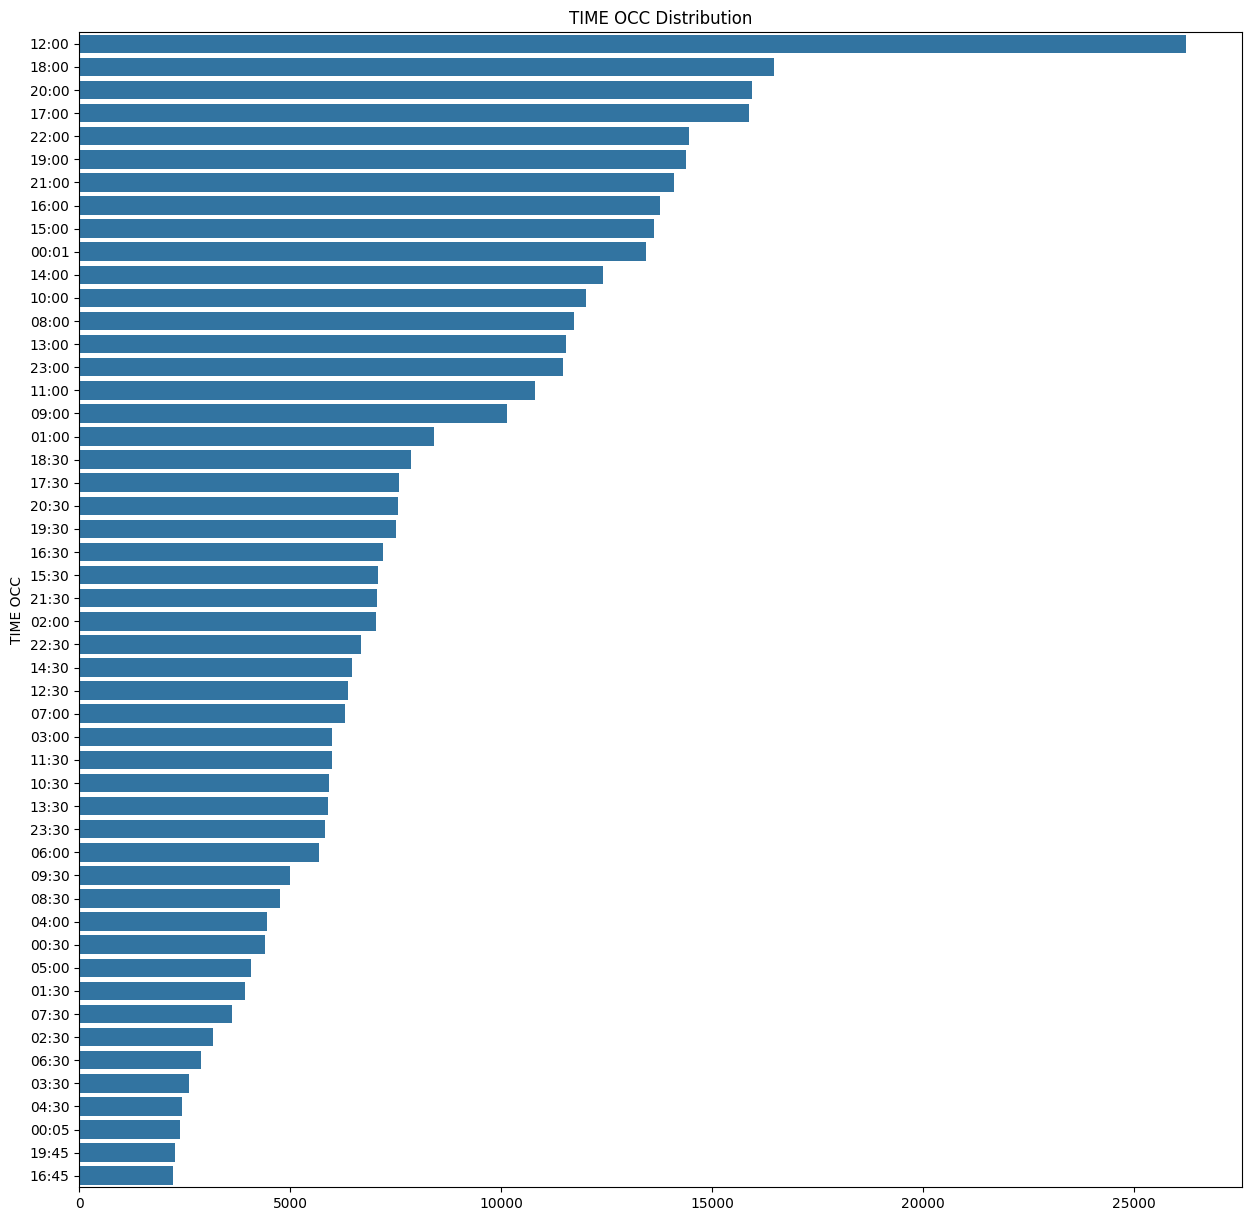

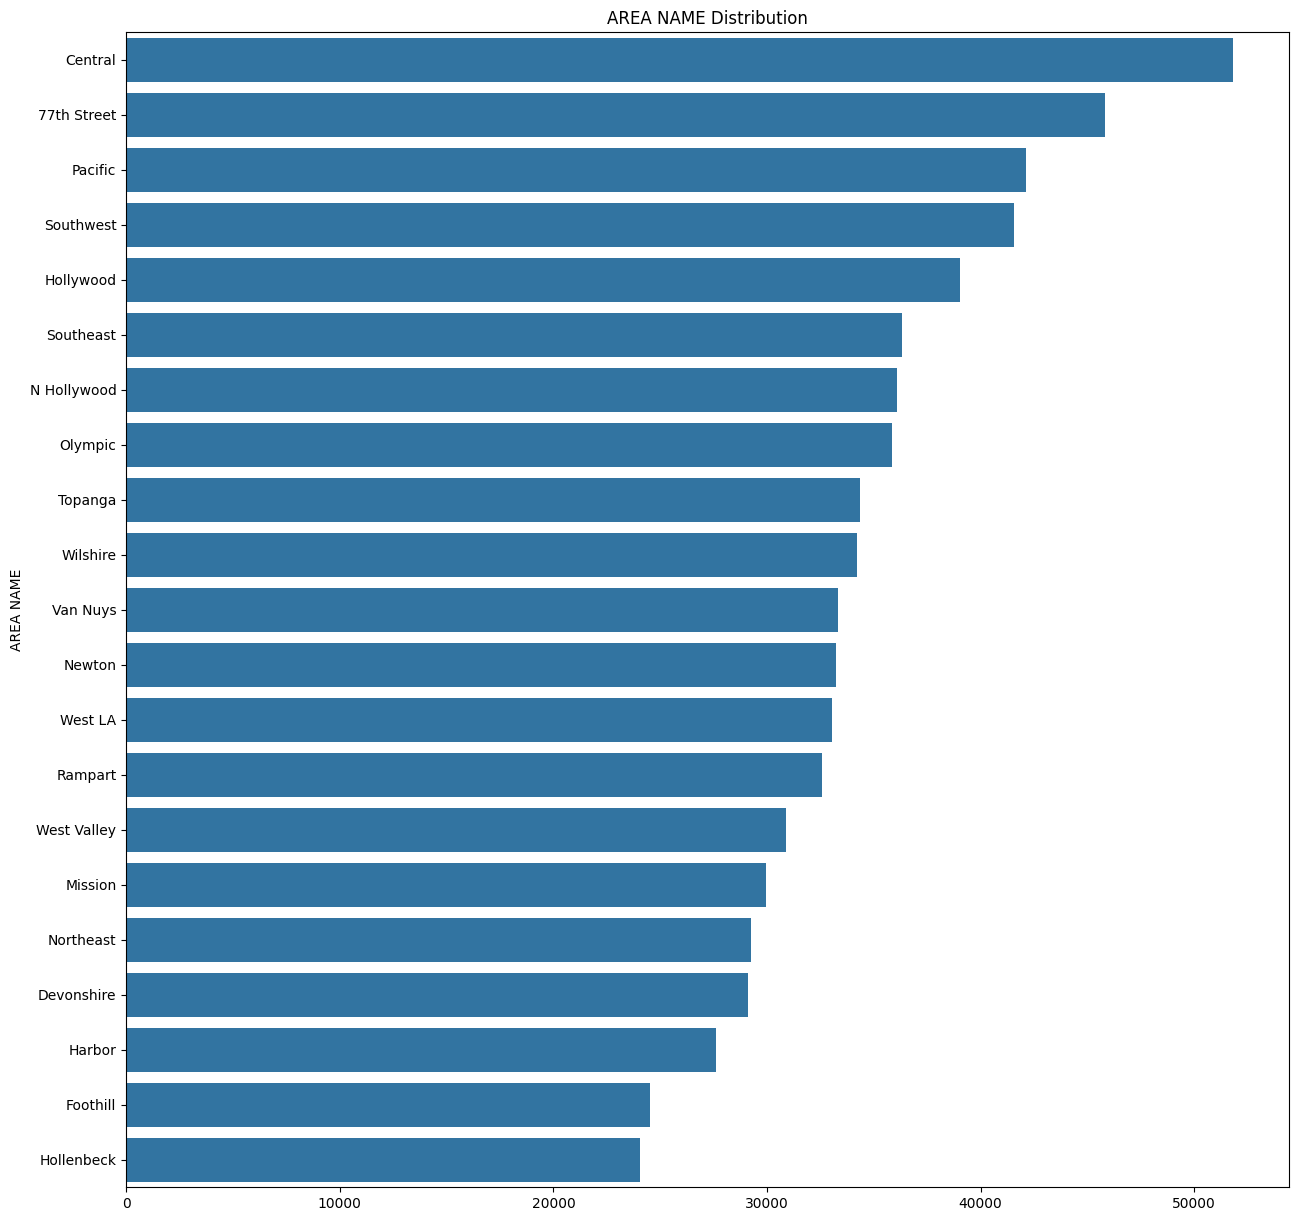

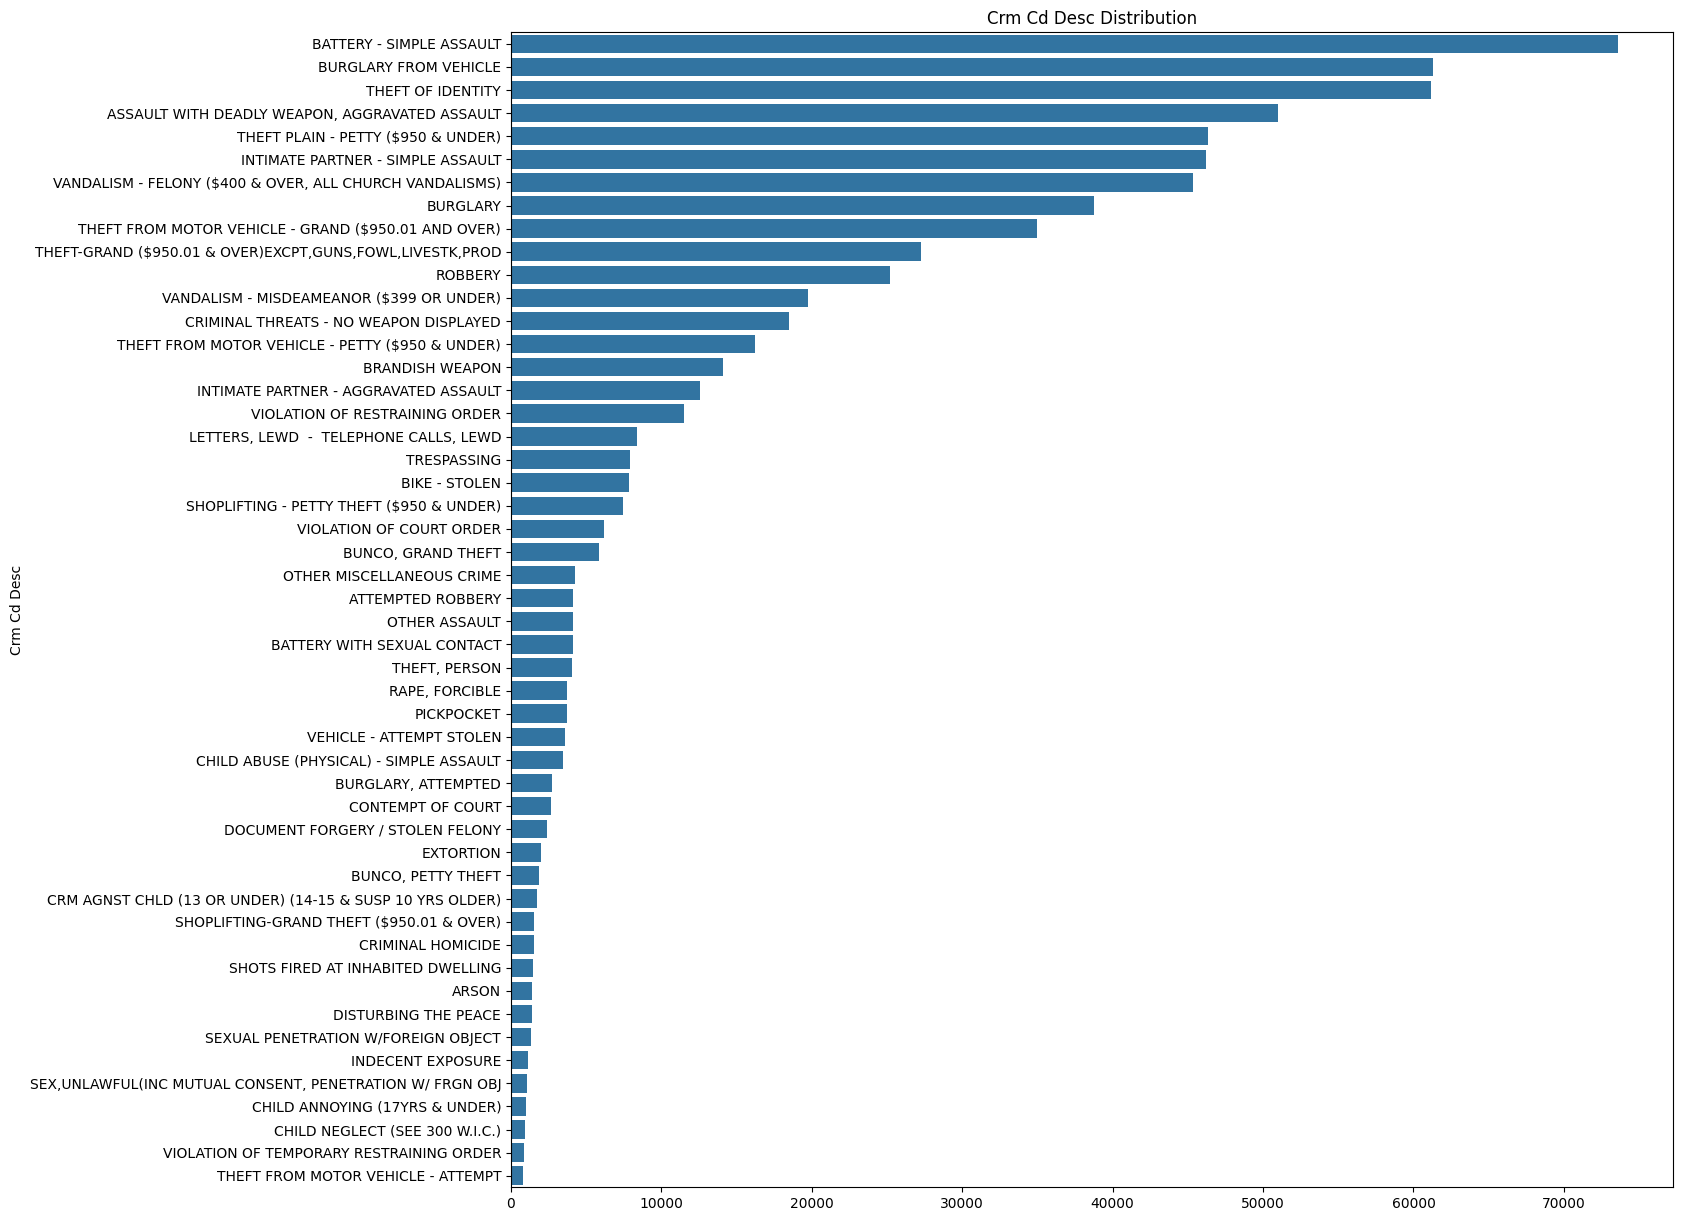

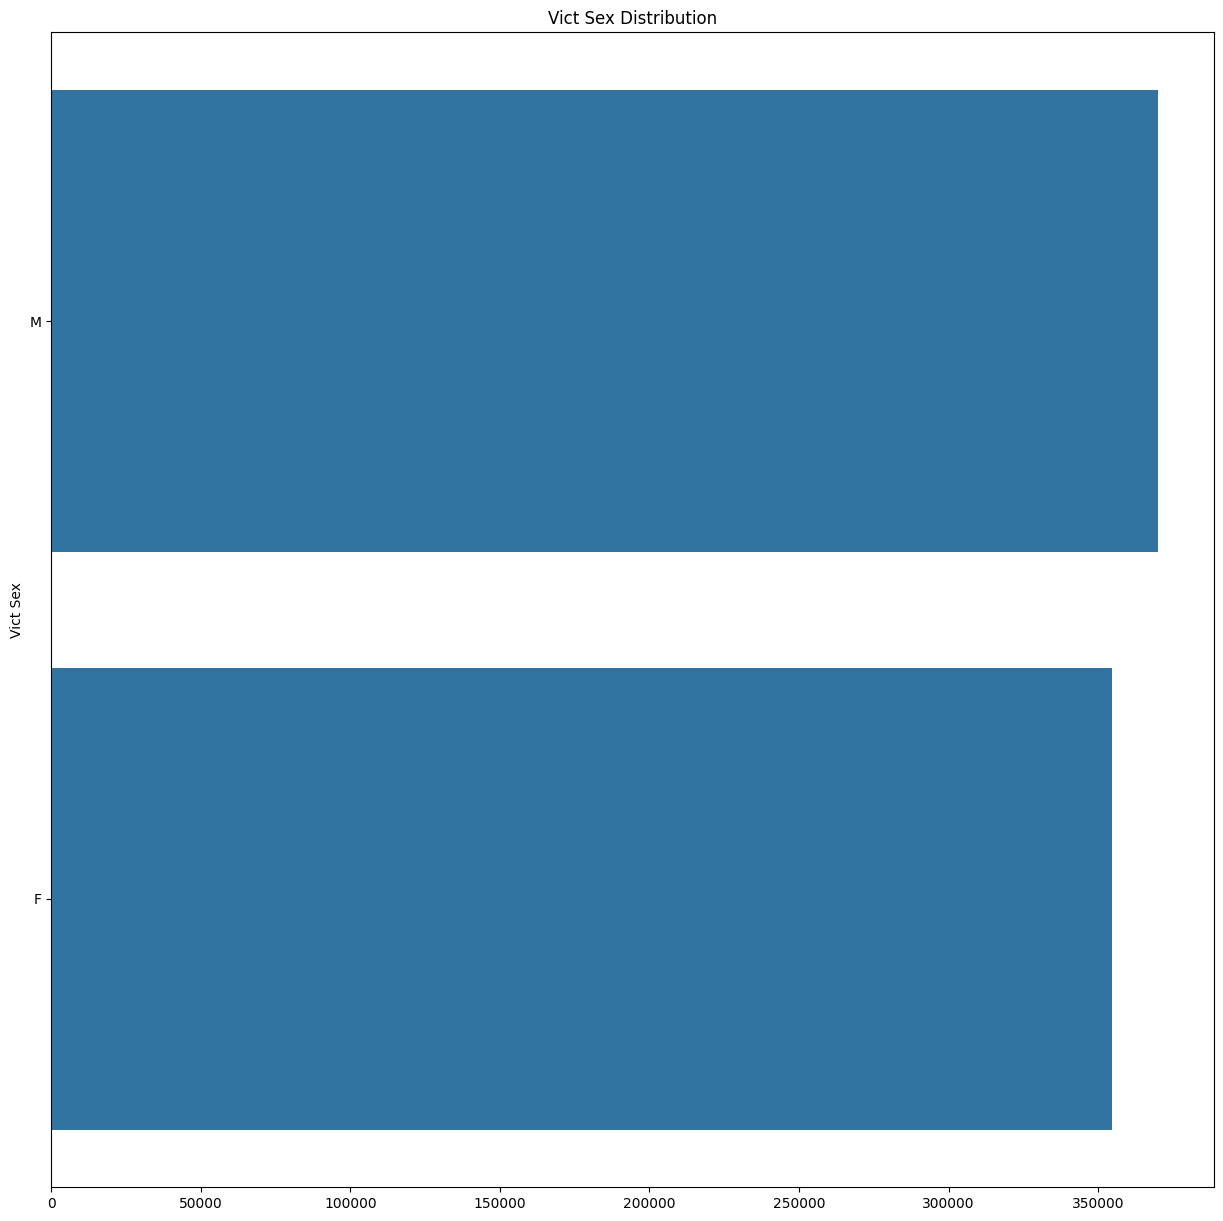

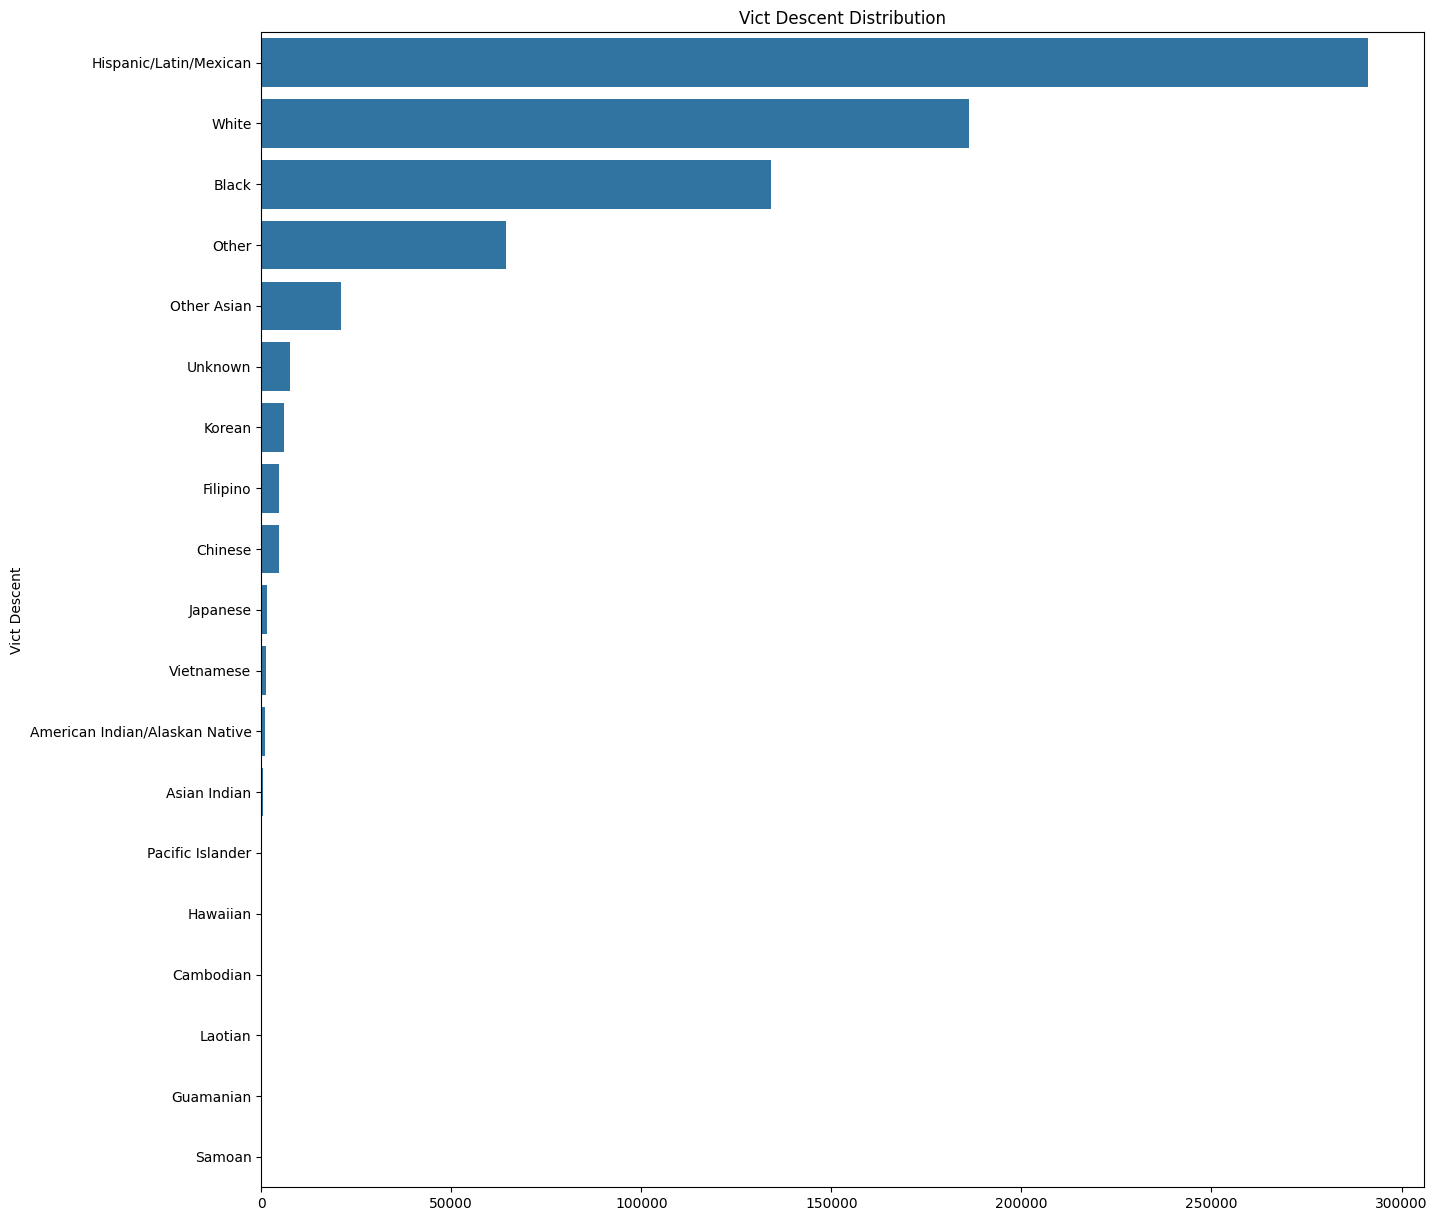

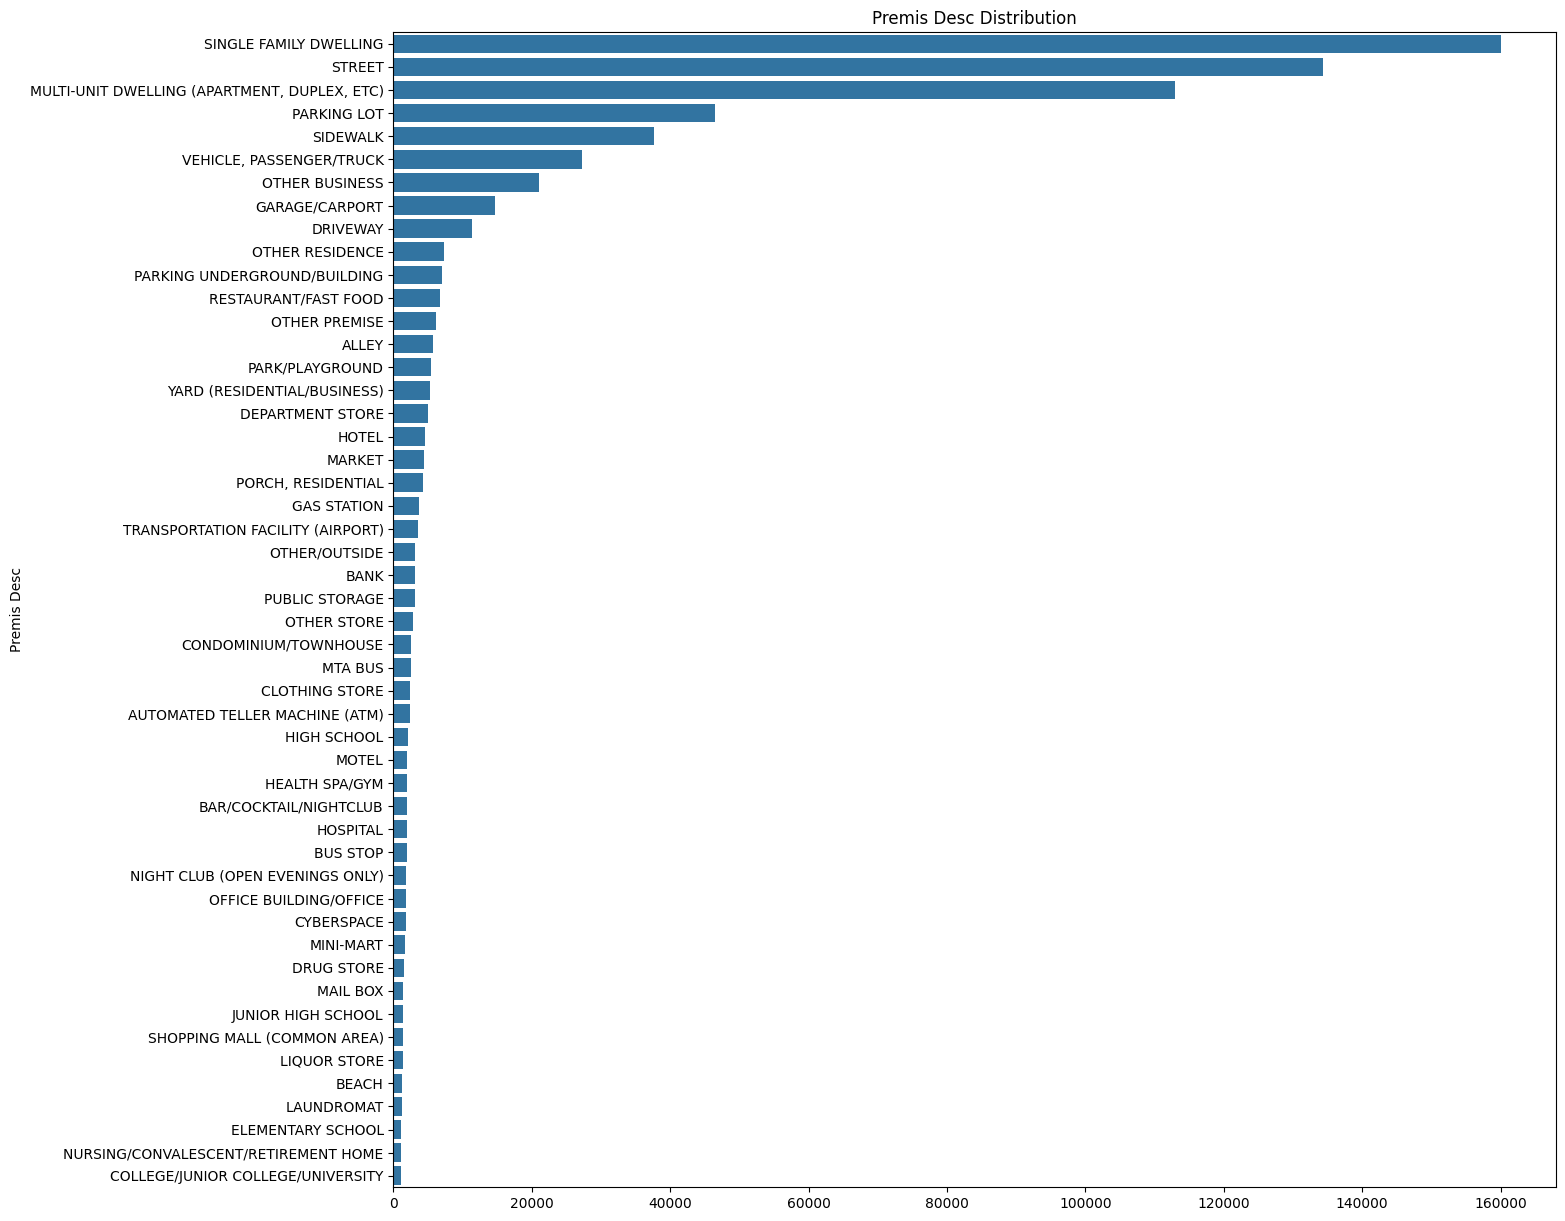

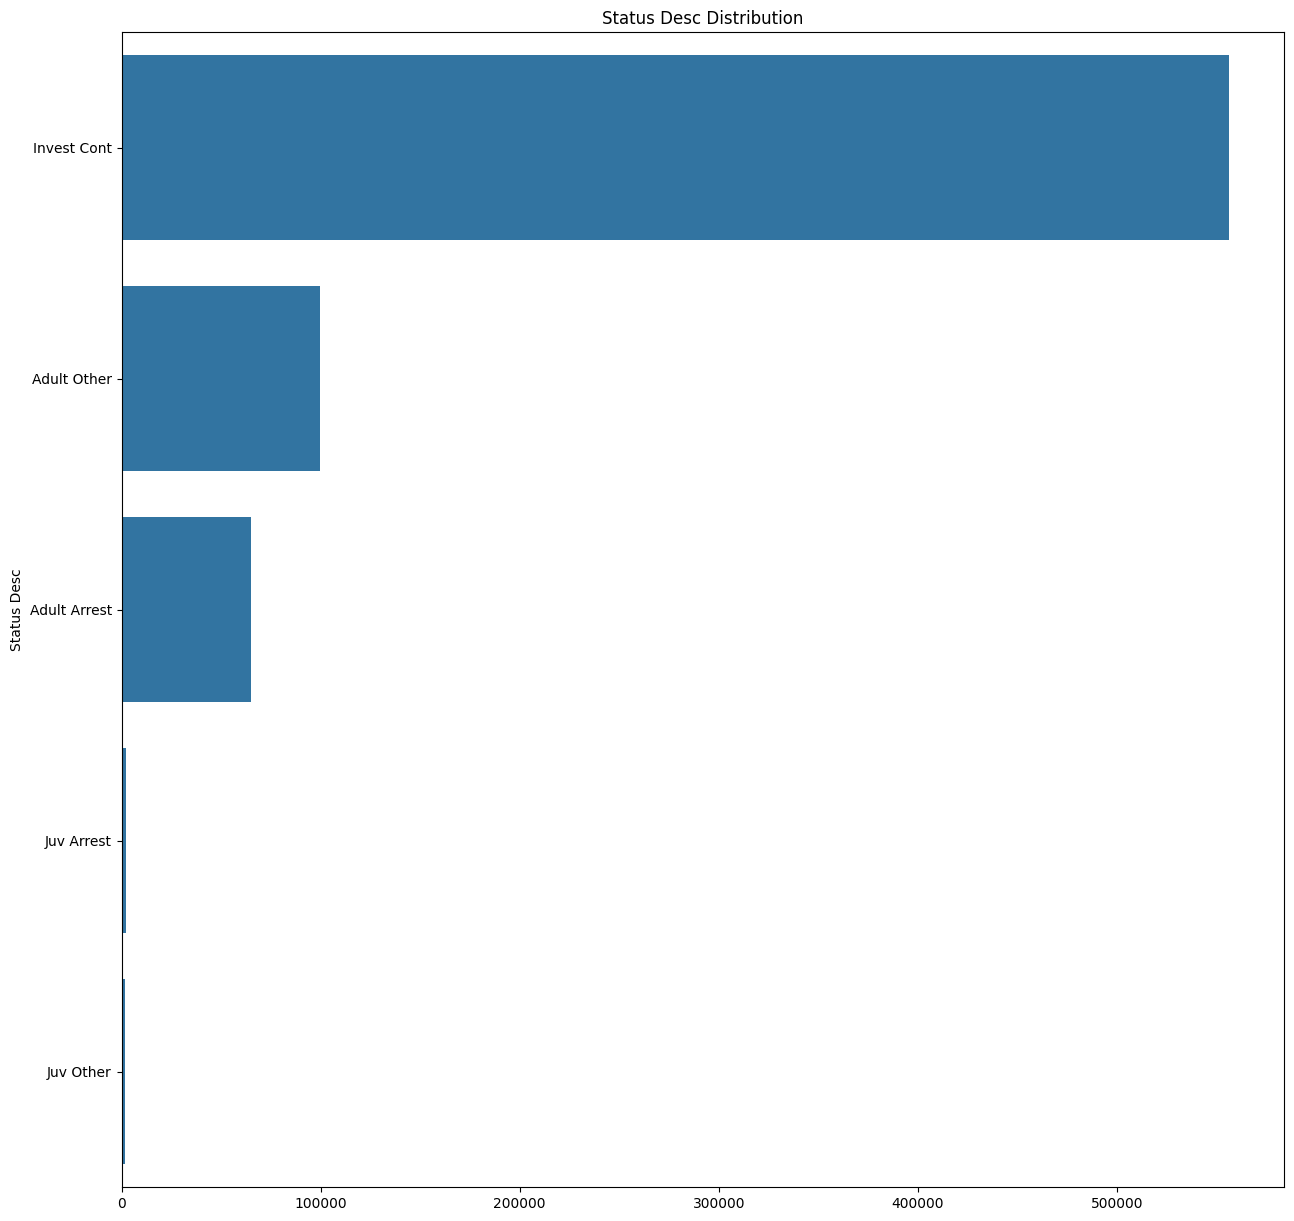

In [23]:
for col in all_columns:
    if col not in ["Date Rptd", "DATE OCC", "DATE OCC", "Vict Age", "LOCATION",
                   "LAT", "LON"]:
        if col == "TIME OCC":
            selected = db[col].dt.strftime('%H:%M').value_counts().head(50)
        else:
            selected = db[col].value_counts().head(50)
        plt.figure(figsize=(15, 15))
        sns.barplot(x=selected.values, y=selected.index)
        plt.title(f'{col} Distribution')
        plt.show()

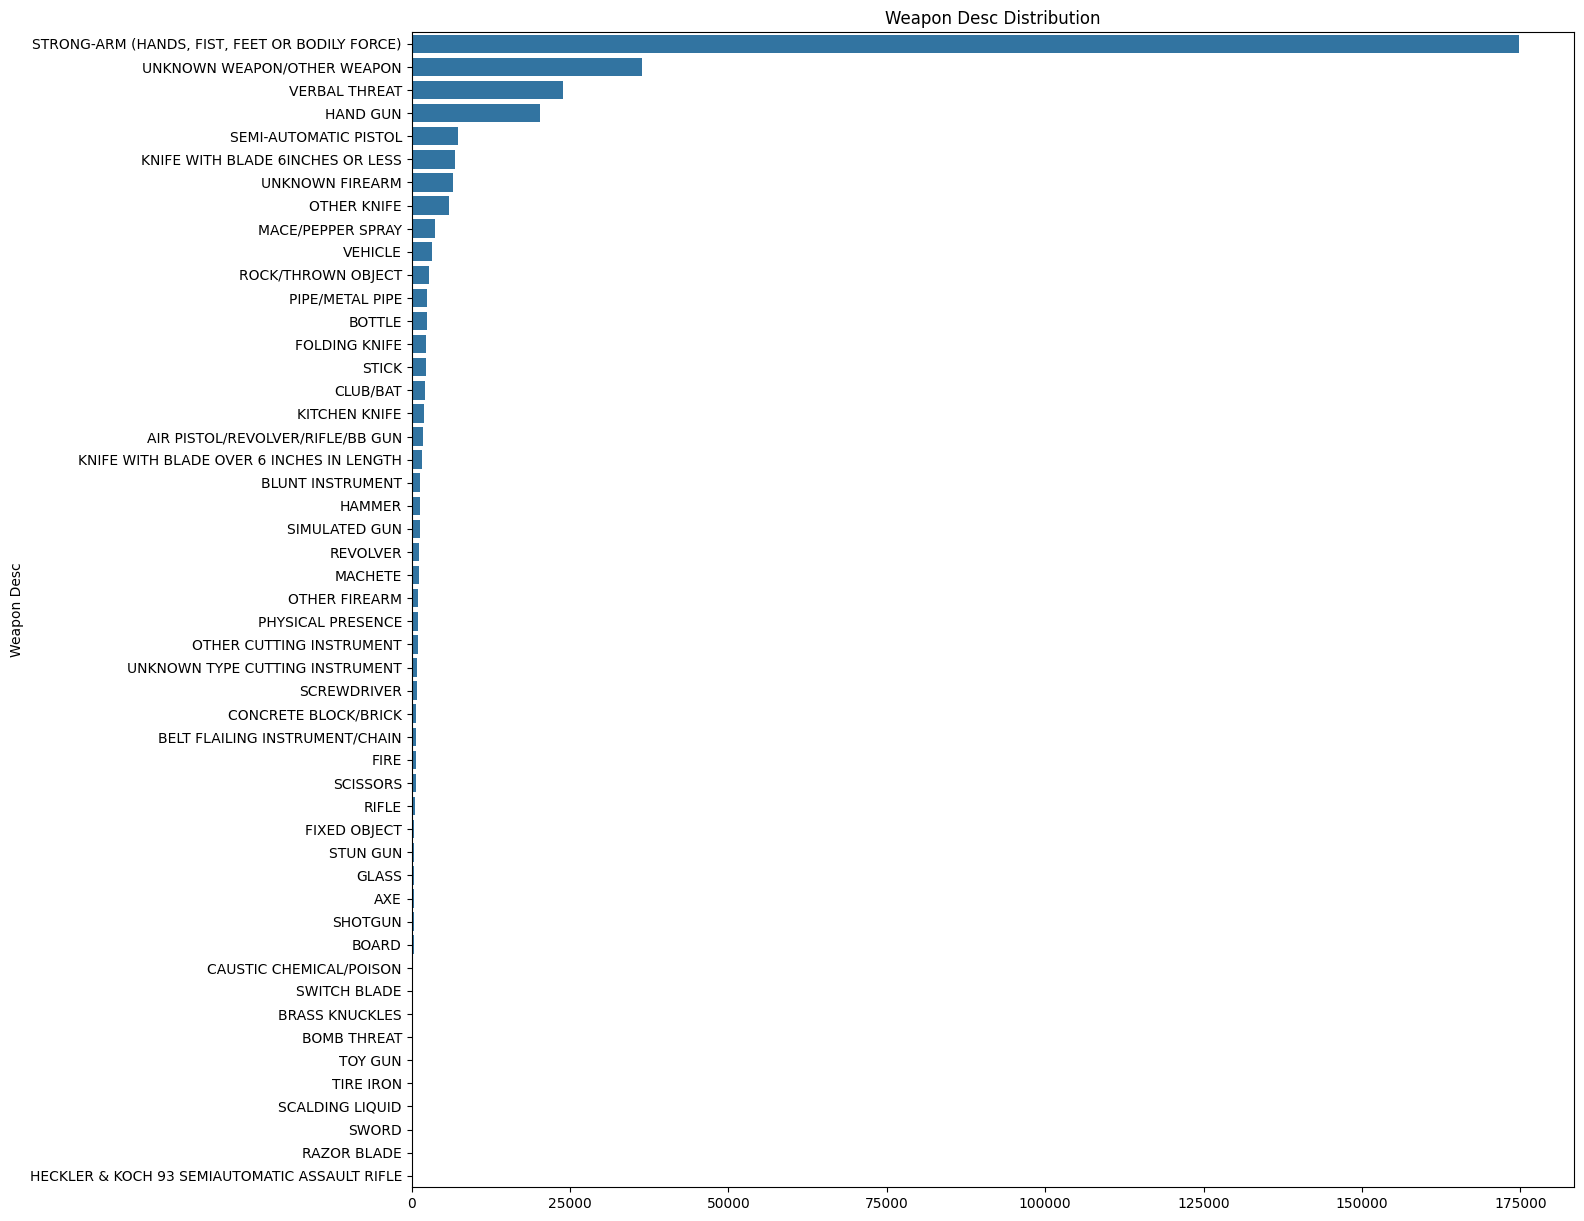

In [24]:
selected = Weapon_Desc.value_counts().head(50)
plt.figure(figsize=(15, 15))
sns.barplot(x=selected.values, y=selected.index)
plt.title("Weapon Desc Distribution")
plt.show()

From these Distribuitons We can infer some things

*   12:00 AM is the time with the highest number of incidents
*   Central is the District area with most occurrence
*   Simple Assult of battery is the most frequent type of crime
*   There's no noticeable difference of number of cases beteween male and female victim genres
*   Most of the victims are primarly Hispanic/Latin/Mexican descentent
*   The ambience most frenquently targeted are single family dwelling
*   Most cases still under investigation
*   Most of the crimes are commited using strong-arm (Hands, fist, feet or bodily force)

Now, let's do victim's age histogram and get some information:

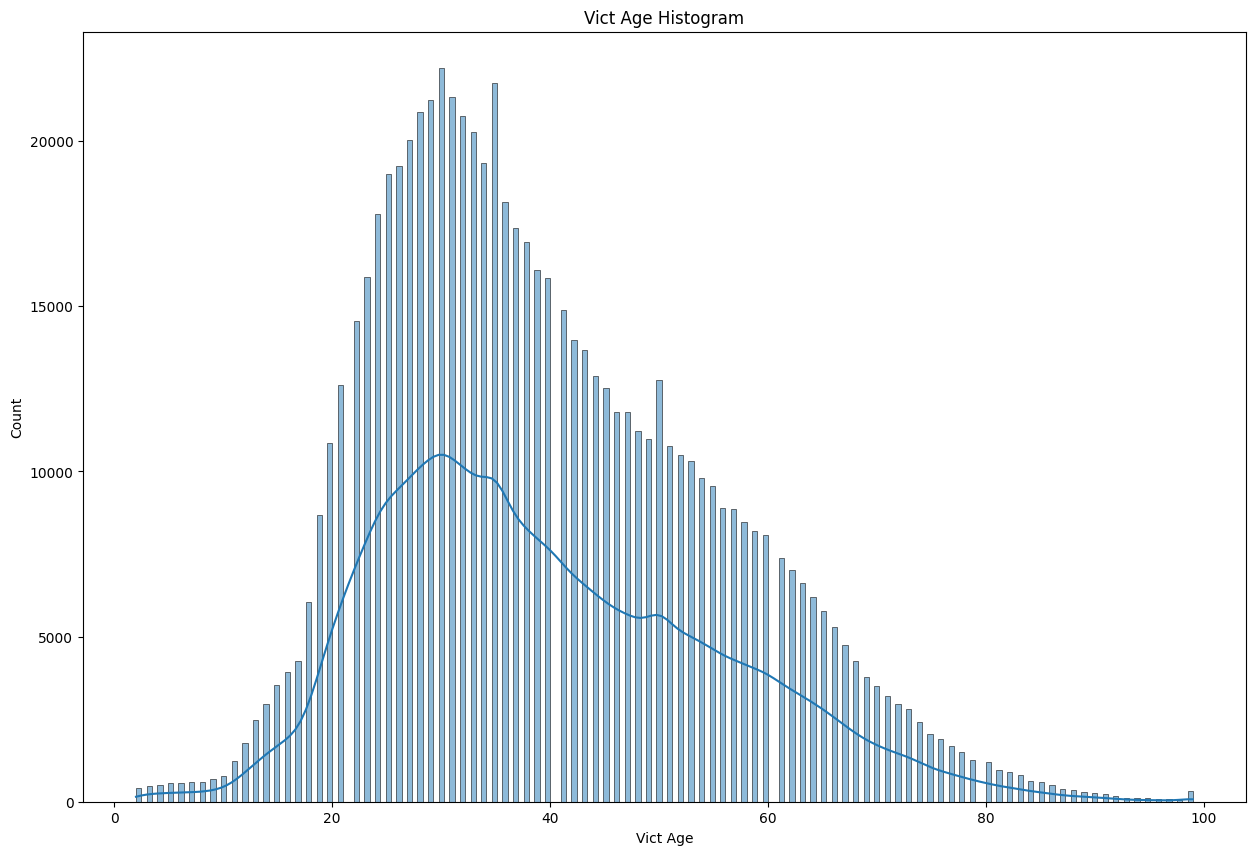


Descritive estatistics for Vict Age:

count    724786.000000
mean         39.724877
std          15.532278
min           2.000000
25%          28.000000
50%          37.000000
75%          50.000000
max          99.000000
Name: Vict Age, dtype: float64


In [25]:
for col in quantitatives:
    plt.figure(figsize=(15, 10))
    sns.histplot(db[col], kde=True)
    plt.title(f'{col} Histogram')
    plt.show()

    print(f"\nDescritive estatistics for {col}:\n\n{db[col].describe()}")

As we can see, the major part of victim's age is between twelve and forty, or tirthty years old by the mean.

Let's do a time series graph of crimes frequency:

/tmp/ipython-input-448224277.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  timeline = time.groupby(pd.Grouper(freq='M')).sum()


(array([17897., 18262., 18628., 18993., 19358., 19723., 20089.]),
 [Text(17897.0, 0, '2019'),
  Text(18262.0, 0, '2020'),
  Text(18628.0, 0, '2021'),
  Text(18993.0, 0, '2022'),
  Text(19358.0, 0, '2023'),
  Text(19723.0, 0, '2024'),
  Text(20089.0, 0, '2025')])

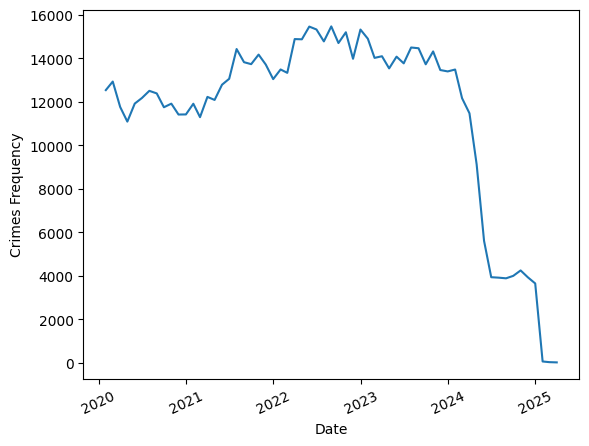

In [26]:
time = pd.to_datetime(db["Date Rptd"]).value_counts().sort_index()
timeline = time.groupby(pd.Grouper(freq='M')).sum()
sns.lineplot(x = timeline.index, y = timeline.values)
plt.xlabel("Date")
plt.ylabel("Crimes Frequency")
plt.xticks(rotation = 25)

The crimes number increased sligthly over time, as we see above.

# 3) Dashboarding

In [27]:
!pip install dash


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 50.7 MB/s eta 0:00:00


In [28]:
import dash
from dash import dcc, html
import plotly.graph_objects as go

In [29]:
print(db)

        Date Rptd   DATE OCC            TIME OCC    AREA NAME  \
0      2021-04-11 2020-11-07 1900-01-01 08:45:00  N Hollywood   
1      2020-10-21 2020-10-18 1900-01-01 18:45:00  N Hollywood   
2      2024-12-10 2020-10-30 1900-01-01 12:40:00     Van Nuys   
3      2020-12-24 2020-12-24 1900-01-01 13:10:00     Wilshire   
4      2020-10-03 2020-09-29 1900-01-01 18:30:00      Pacific   
...           ...        ...                 ...          ...   
724781 2025-02-02 2025-02-02 1900-01-01 01:30:00      Topanga   
724782 2025-02-18 2025-02-18 1900-01-01 10:00:00   Hollenbeck   
724783 2025-01-31 2025-01-30 1900-01-01 15:54:00       Newton   
724784 2025-01-17 2025-01-17 1900-01-01 16:00:00   Devonshire   
724785 2025-03-25 2025-03-25 1900-01-01 12:35:00      Mission   

                                              Crm Cd Desc  Vict Age Vict Sex  \
0                                       THEFT OF IDENTITY        31        M   
1          ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT  

In [58]:
db['Premis Desc'].value_counts().index.tolist()
db['Premis Desc'].value_counts().values.tolist()
db['Crm Cd Desc'].value_counts().index.tolist()
db['Crm Cd Desc'].value_counts().values.tolist()
Weapon_Desc.value_counts().index.tolist()
Weapon_Desc.value_counts().values.tolist()

[174761,
 36390,
 23846,
 20182,
 7267,
 6838,
 6582,
 5879,
 3730,
 3260,
 2739,
 2469,
 2415,
 2266,
 2249,
 2088,
 1921,
 1864,
 1697,
 1387,
 1355,
 1252,
 1186,
 1144,
 948,
 945,
 932,
 884,
 783,
 706,
 688,
 681,
 659,
 496,
 406,
 395,
 335,
 323,
 315,
 310,
 241,
 234,
 208,
 194,
 157,
 149,
 145,
 138,
 118,
 104,
 92,
 86,
 77,
 69,
 66,
 65,
 55,
 54,
 53,
 50,
 41,
 36,
 33,
 29,
 28,
 28,
 22,
 19,
 15,
 14,
 13,
 12,
 10,
 9,
 3,
 2,
 2,
 2,
 1]

In [86]:
from collections import Counter


app = dash.Dash(__name__)


db_hour = db['TIME OCC'].dt.strftime('%H:%M')

hours = []
for time_str in db_hour:
    hour, minute = map(int, time_str.split(':'))
    if minute >= 50:
        hour = (hour + 1) % 24
    hours.append(hour)


cont_hours = Counter(hours)
frequencias = [cont_hours.get(i, 0) for i in range(24)]
min_val = min(frequencias)
max_val = max(frequencias)

colors = [
    f'rgba(255, {int(max(0, 255 - (val / max_val) * 255))}, {int(max(0, 255 - (val / max_val) * 255))}, 1)'
    for val in frequencias
]

fig = go.Figure(data=go.Barpolar(
    r=frequencias,
    theta=[i * 15 for i in range(24)],
    width=[12 for _ in range(24)],
    marker_color=colors,
    opacity=0.8
))

fig.update_layout(
    height=1000,
    width=700,
    polar=dict(
        radialaxis=dict(
            range=[0, max_val * 1.05],
            showticklabels=True,
            ticks=''
        ),
        angularaxis=dict(
            tickmode='array',
            tickvals=[i * 15 for i in range(24)],
            ticktext=[f'{i}h' for i in range(24)],
            rotation=90,
            direction="clockwise"
        )
    ),
    showlegend=False,
    title='Frequência de Crimes por Hora do Dia'
)

cont_premis = Counter(hours)
frequencias = [cont_hours.get(i, 0) for i in range(24)]
premis_labels = db['Premis Desc'].value_counts().head(30).index.tolist()
premis_freqs = db['Premis Desc'].value_counts().head(30).values.tolist()

crm_labels = db['Crm Cd Desc'].value_counts().head(30).index.tolist()
crm_freqs = db['Crm Cd Desc'].value_counts().head(30).values.tolist()

weapon_labels = Weapon_Desc.value_counts().head(30).index.tolist()
weapon_freqs = Weapon_Desc.value_counts().head(30).values.tolist()

fig_premis = go.Figure(go.Bar(
    x=premis_freqs,
    y=premis_labels,
    orientation='h',
    marker=dict(
        color='rgba(55, 128, 191, 0.7)',
        line=dict(width=0)
    )
))
fig_premis.update_layout(
    title='Distribuição da Premissa', xaxis_title='Frequência', yaxis_title='Descrição da Premissa',
    margin=dict(l=260, r=20, t=60, b=40),
    bargroupgap=0.5,
    height=1000,
    width=800,
    yaxis=dict(automargin=True),
    font=dict(family="Arial", size=10)
)

fig_crm = go.Figure(go.Bar(
    x=crm_freqs,
    y=crm_labels,
    orientation='h',
    marker=dict(
        color='rgba(55, 128, 191, 0.7)',
        line=dict(width=0)
    )
))
fig_crm.update_layout(
    title='Distribuição de Crime', xaxis_title='Frequência', yaxis_title='Descição do Crime',
    margin=dict(l=260, r=120, t=60, b=40),
    height=1000,
    width=800,
    yaxis=dict(automargin=True),
    font=dict(family="Arial", size=10)
)

fig_weapon = go.Figure(go.Bar(
    x=weapon_freqs,
    y=weapon_labels,
    orientation='h',
    marker=dict(
        color='rgba(55, 128, 191, 0.7)',
        line=dict(width=0)
    )
))
fig_weapon.update_layout(
    title='Distribuição de Armamento', xaxis_title='Frequência', yaxis_title='Descrição de Armas',
    margin=dict(l=260, r=20, t=60, b=40),
    height=1000,
    width=800,
    yaxis=dict(automargin=True),
    font=dict(family="Arial", size=10)
)


app.layout = html.Div([
    html.H1(
    'Painel de Crimes em Los Angeles',
    style={
        'textAlign': 'center',
        'backgroundColor': 'white',
        'padding': '10px'
    }
    ),
    html.Div([
        dcc.Graph(figure=fig, style={"width": "49%", "display": "inline-block"}),
        dcc.Graph(figure=fig_premis, style={"width": "49%", "display": "inline-block"}),
    ]),
    html.Div([
        dcc.Graph(figure=fig_crm, style={"width": "49%", "display": "inline-block"}),
        dcc.Graph(figure=fig_weapon, style={"width": "49%", "display": "inline-block"}),
    ]),
])

if __name__ == '__main__':
    app.run(debug=True)

<IPython.core.display.Javascript object>